# Chapter 14 - Backtesting Statistics

## Preparation

Note: The exercise text refers to E-mini S&P 500 futures, but these calculations use the locally prepared IVE dollar-bar dataset (`data/processed/clean_IVE_tickbidask.parquet`).


In [17]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm
from random import gauss
from itertools import product

from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC

from utils.data_paths import IVE_TICKS
from utils.sampling_bars import dollar_bar
from utils.backtest_stats import get_statistics, get_psr, get_dsr_s_star


%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

df = pd.read_parquet(IVE_TICKS)

dollar_bars = dollar_bar(df)

In [18]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low
date,,,,,,,,
2009-09-28 09:31:50,50.75,50.73,50.76,300.0,15225.00,1.0,50.75,50.75
2009-09-28 09:33:02,50.81,50.80,50.81,800.0,40648.00,2.0,50.81,50.81
2009-09-28 09:34:04,50.82,50.80,50.82,100.0,5082.00,1.0,50.82,50.82
2009-09-28 09:38:28,50.81,50.79,50.81,195.0,9907.95,1.0,50.81,50.81
2009-09-28 09:42:17,50.85,50.83,50.85,200.0,10170.00,2.0,50.85,50.85


<Axes: xlabel='date'>

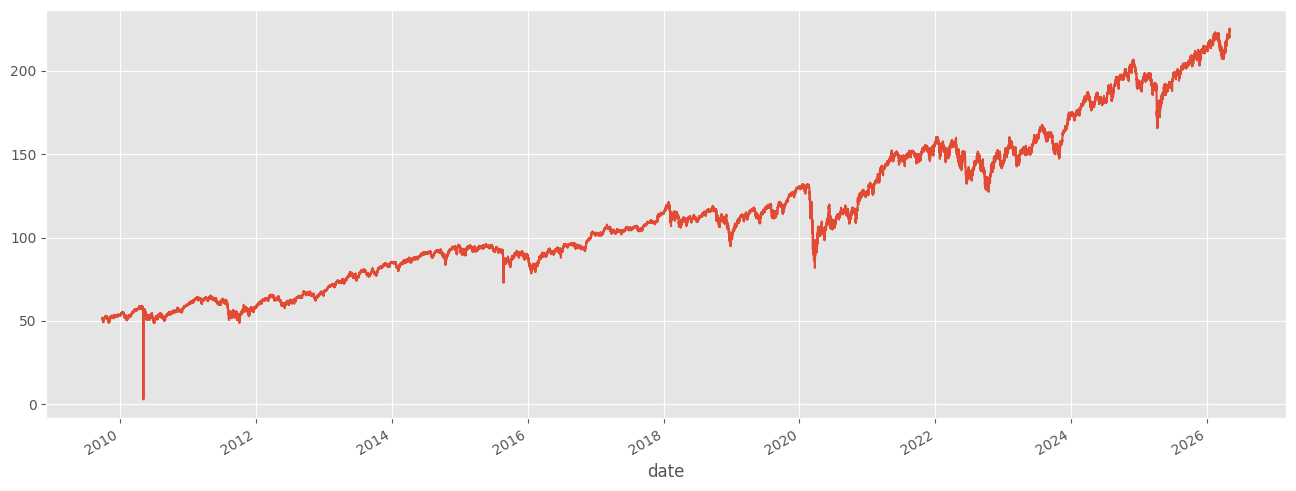

In [19]:
dollar_bars["price"].plot()

## 1. A strategy exhibits a high turnover, high leverage, and high number of bets, with a short holding period, low return on execution costs, and a high Sharpe ratio. Is it likely to have large capacity? What kind of strategy do you think it is?

The strategy may be statistical arbitrage, high-frequency market making, or high-frequency mean reversion strategy. It will have a low capacity, since Capacity ∝ (Average Daily Volume × Holding Period) / Turnover, and this strategy have short holding period and high turnover, so for sure it will have a low capacity.

The reason of the high Sharpe ratio can be attributed to the Fundamental Law of Active Management, where IR ≈ IC × √N, and N is our number of independent bets. Since this strategy possesses a high number of bets, it will inflate the sharpe ratio by the factor of √N, while it may have a low IC.

High SR can also be fragile after costs, latency, crowding, and financing.

## 2. On the dollar bars dataset for E-mini S&P 500 futures, compute

* (a) HHI index on positive returns
* (b) HHI index on negative returns
* (c) HHI index on time between bars
* (d) The 95-percentile DD
* (e) The 95-percentile TuW
* (f) Annualized average return
* (g) Average returns from hits (positive returns)
* (h) Average returns from misses (negative returns)
* (i) Annualized SR
* (j) Information ratio, where the benchmark is the risk-free rate
* (k) PSR
* (l) DSR, where we assume there were 100 trials, and the variance of the trials' SR was 0.5

In [20]:
obs_per_year = dollar_bars.shape[0] / ((dollar_bars.index[-1] - dollar_bars.index[0]) / pd.Timedelta(days=365.2425))
print(f"Average number of observations per year: {obs_per_year:.2f}")

annualized_target_sr = 1.1

stats = get_statistics(
    dollar_bars["price"],
    obs_per_year=obs_per_year,
    target_sr=annualized_target_sr,
    dsr_var_trial_sr=0.5,
    dsr_num_trial=100,
)

stats

Average number of observations per year: 87023.25


{'hhi_positive': np.float64(0.0039445965160442705),
 'hhi_negative': np.float64(2.9683134488569936e-05),
 'hhi_time_between_bars': np.float64(0.0013394099476008244),
 'dd_95': np.float64(0.007926539731924226),
 'tuw_95': np.float64(0.007855571410451541),
 'annualized_return': np.float64(0.8771167140711478),
 'average_return_from_hits': np.float64(0.00028232032521883),
 'average_return_from_misses': np.float64(-0.00029265257088036367),
 'annualized_sr': np.float64(0.2641096055807411),
 'information_ratio': np.float64(-393.0541281761358),
 'psr': np.float64(0.0),
 'dsr': np.float64(9.16887804066881e-40),
 'dsr_s_star': np.float64(0.00606584573451332)}

## 3. Consider a strategy that is long one futures contract on even years, and is short one futures contract on odd years.

In [21]:
signals = pd.Series(index=dollar_bars.index)
signals[signals.index.year % 2 != 0] = -1 # odd year, short it
signals[signals.index.year % 2 == 0] = 1  # even year, long it

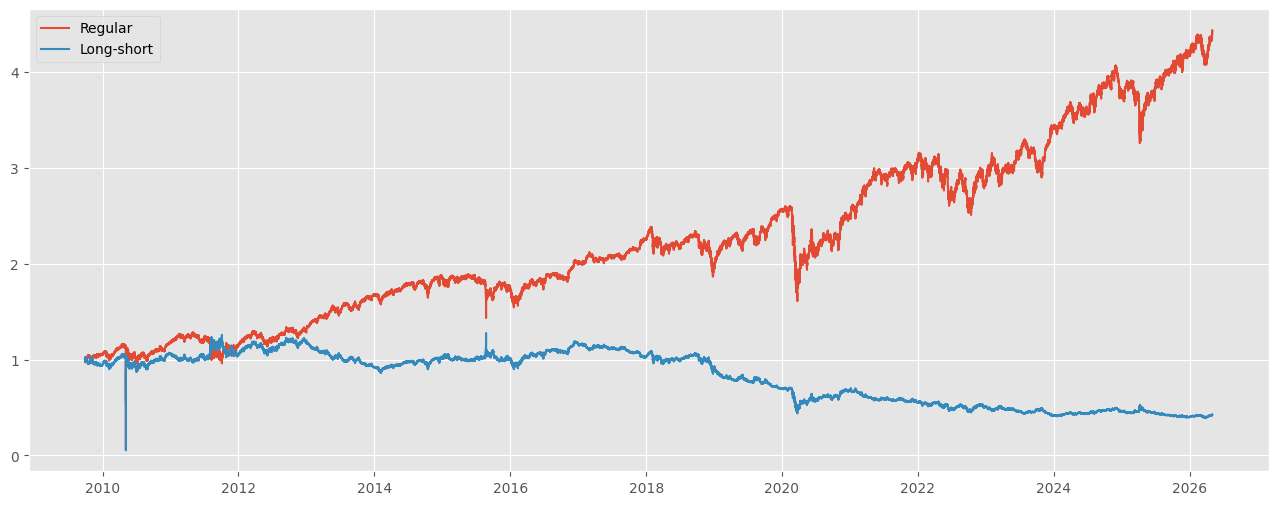

In [22]:
returns = dollar_bars['price'].pct_change().dropna()
long_short_returns = returns * signals.reindex(returns.index)

reg_pnl = (1 + returns).cumprod()
strat_pnl = (1 + long_short_returns).cumprod()

plt.figure(figsize=(16, 6))
plt.plot(reg_pnl, label='Regular')
plt.plot(strat_pnl, label='Long-short')
plt.legend();

### a. Repeat the calculations from exercise 2.

In [23]:
long_short_stats = get_statistics(
    strat_pnl.dropna(),
    obs_per_year=obs_per_year,
    target_sr=annualized_target_sr,
    dsr_var_trial_sr=0.5,
    dsr_num_trial=100,
)
long_short_stats

{'hhi_positive': np.float64(0.0039880430722562575),
 'hhi_negative': np.float64(2.928307702739081e-05),
 'hhi_time_between_bars': np.float64(0.0013394181372292336),
 'dd_95': np.float64(0.0280088161199135),
 'tuw_95': np.float64(0.007967059868087264),
 'annualized_return': np.float64(0.7360337972638878),
 'average_return_from_hits': np.float64(0.0002812784224255674),
 'average_return_from_misses': np.float64(-0.0002937852196402313),
 'annualized_sr': np.float64(0.22162786678303054),
 'information_ratio': np.float64(-393.05409095542643),
 'psr': np.float64(0.0),
 'dsr': np.float64(9.391348097010175e-31),
 'dsr_s_star': np.float64(0.00606584573451332)}

### b. What is the correlation to the underlying?

In [24]:
# first exclude the extreme return
filtered_long_short_returns = long_short_returns[long_short_returns.abs() < 0.1]
filtered_returns = returns[returns.abs() < 0.1]

corr = filtered_long_short_returns.corr(filtered_returns)
corr

np.float64(0.20730620440887262)

## 4. The results from a 2-year backtest are that monthly returns have a mean of 3.6%, and a standard deviation of 0.079%.

* a. What is the SR?
* b. What is the annualized SR?

In [25]:
r_mean = 0.036
stated_r_std = 0.00079  # 0.079% expressed as a decimal
assumed_r_std = 0.079   # likely intended value: 7.9%

stated_sr = r_mean / stated_r_std
stated_annualized_sr = stated_sr * np.sqrt(12)

sr = r_mean / assumed_r_std
annualized_sr = sr * np.sqrt(12)

print(f"Using the stated 0.079% monthly std: SR={stated_sr:.6f}, annualized SR={stated_annualized_sr:.6f}")
print(f"Using the likely intended 7.9% monthly std: SR={sr:.6f}, annualized SR={annualized_sr:.6f}")

Using the stated 0.079% monthly std: SR=45.569620, annualized SR=157.857795
Using the likely intended 7.9% monthly std: SR=0.455696, annualized SR=1.578578


## 5. Following on exercise 4:

### a. The returns have a skewness of 0 and a kurtosis of 3. What is the PSR?

In [26]:
skewness_1 = 0
kurtosis_1 = 3

target_sr = 1.5 / np.sqrt(12) # de-annualized the benchmark sr
psr = get_psr(sr, skewness_1, kurtosis_1, T=24, target_sr=target_sr)

print(f"The PSR with skewness of {skewness_1} and kurtosis of {kurtosis_1} is {psr:3f}")

The PSR with skewness of 0 and kurtosis of 3 is 0.541234


### b. The returns have a skewness of -2.448 and a kurtosis of 10.164. What is  the PSR?

In [27]:
skewness_2 = -2.448
kurtosis_2 = 10.164

psr_2 = get_psr(sr, skewness_2, kurtosis_2, T=24, target_sr=target_sr)

print(f"The PSR with skewness of {skewness_2} and kurtosis of {kurtosis_2} is {psr_2:3f}")

The PSR with skewness of -2.448 and kurtosis of 10.164 is 0.526940


## 6. What would be the PSR from 4.b, if the backtest had been for a length of 3 years?

In [28]:
psr_2 = get_psr(sr, skewness_2, kurtosis_2, T=3 * 12, target_sr=target_sr)

print(f"The PSR with skewness of {skewness_2}, kurtosis of {kurtosis_2}, and T of {3 * 12} is {psr_2:3f}")

The PSR with skewness of -2.448, kurtosis of 10.164, and T of 36 is 0.533220


For this assumed return distribution, the PSR rises when `T` increases because the observed SR is above the benchmark. If the observed SR were below the benchmark, increasing `T` would push PSR lower.

## 7. A 5-year backtest has an annualized SR of 2.5, computed on daily returns. The skewness is -3 and the kurtosis is 10.

### a. What is the PSR?

In [29]:
annualized_sr = 2.5
sr = annualized_sr / np.sqrt(252)
skewness_3 = -3
kurtosis_3 = 10

target_sr = 1.5 / np.sqrt(252)

psr_3 = get_psr(sr, skewness_3, kurtosis_3, T=5 * 252, target_sr=target_sr)

print(f"The PSR with annualized SR of {annualized_sr}, skewness of {skewness_3}, kurtosis of {kurtosis_3}, and T of {5 * 252} is {psr_3:3f}")

The PSR with annualized SR of 2.5, skewness of -3, kurtosis of 10, and T of 1260 is 0.964702


### b. In order to find that best result, 100 trials were conducted. The variance of the Sharpe ratios on those trials is 0.5. What is the DSR?

In [30]:
num_trials = 100
var_trial_sr = 0.5

annualized_dsr_defined_sr = get_dsr_s_star(var_trial_sr, num_trials)
dsr_defined_sr = annualized_dsr_defined_sr / np.sqrt(252)
dsr = get_psr(sr, skewness_3, kurtosis_3, T=5 * 252, target_sr=dsr_defined_sr)

print(f"The annualized S* estimated by DSR is {annualized_dsr_defined_sr:.6f}")
print(f"The daily S* used in PSR is {dsr_defined_sr:.6f}")
print(f"The DSR with {num_trials} trials and a variance of {var_trial_sr} is {dsr:.6f}")

The annualized S* estimated by DSR is 1.789406
The daily S* used in PSR is 0.112722
The DSR with 100 trials and a variance of 0.5 is 0.900569
